In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessesing

## Training image Preprocessing using Keras

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 33116 files belonging to 18 classes.


## Test image preprocessing

In [3]:
testing_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 7440 files belonging to 18 classes.


In [4]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 18), dtype=tf.float32, name=None))>

In [5]:
for x, y in training_set:
    print (x, x.shape)
    print (y, y.shape)
    break

# AT A Time 32 training examples is passed to the model

tf.Tensor(
[[[[156.25 142.25 142.25]
   [160.   146.   146.  ]
   [150.75 136.75 136.75]
   ...
   [164.25 150.25 150.25]
   [177.75 163.75 163.75]
   [170.75 156.75 156.75]]

  [[153.   139.   139.  ]
   [164.   150.   150.  ]
   [179.5  165.5  165.5 ]
   ...
   [168.5  154.5  154.5 ]
   [166.25 152.25 152.25]
   [167.5  153.5  153.5 ]]

  [[168.75 154.75 154.75]
   [149.   135.   135.  ]
   [154.   140.   140.  ]
   ...
   [170.75 156.75 156.75]
   [168.25 154.25 154.25]
   [178.25 164.25 164.25]]

  ...

  [[170.5  152.5  152.5 ]
   [169.75 151.75 151.75]
   [156.75 138.75 138.75]
   ...
   [160.75 142.75 142.75]
   [155.75 137.75 137.75]
   [163.25 145.25 145.25]]

  [[161.   143.   143.  ]
   [161.75 143.75 143.75]
   [157.25 139.25 139.25]
   ...
   [166.75 148.75 148.75]
   [158.75 140.75 140.75]
   [159.5  141.5  141.5 ]]

  [[160.25 142.25 142.25]
   [145.75 127.75 127.75]
   [163.5  145.5  145.5 ]
   ...
   [163.25 145.25 145.25]
   [151.5  133.5  133.5 ]
   [157.25 139.25 13

In [6]:
## Building model

## Packages required to build a CNN model

In [6]:
from tensorflow.keras.layers import Dense, Conv2D
from tensorflow.keras.models import Sequential 


In [7]:
from tensorflow.keras.layers import MaxPool2D

In [8]:
from tensorflow.keras.layers import Flatten

In [9]:
from tensorflow.keras.layers import Dropout

In [10]:
model= Sequential()

## Building Convolution Layer

In [13]:
## number of filter = 32, for all 32 filters there are 32 different feautures map

In [11]:
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))


In [12]:
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))  # is input_shape required here??
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))


In [13]:
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))


In [14]:
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))


In [15]:
model.add(Dropout(0.25))

In [16]:
model.add(Flatten())

In [17]:
model.add(Dense(units=1024, activation = 'relu')) # Number of neuron in hidden layer = 1024

In [18]:
model.add(Dropout(0.4))

# output layer

In [19]:
model.add(tf.keras.layers.Dense(units=18,activation='softmax'))

# Compiling Model 

In [20]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

## Model training

In [22]:
training_history = model.fit(x=training_set,validation_data=testing_set,epochs=10)  

Epoch 1/10
1035/1035 [==============================] - 209s 192ms/step - loss: 1.4200 - accuracy: 0.5547 - val_loss: 0.5352 - val_accuracy: 0.8281
Epoch 2/10
1035/1035 [==============================] - 168s 162ms/step - loss: 0.4407 - accuracy: 0.8578 - val_loss: 0.2589 - val_accuracy: 0.9191
Epoch 3/10
1035/1035 [==============================] - 168s 162ms/step - loss: 0.2756 - accuracy: 0.9119 - val_loss: 0.1490 - val_accuracy: 0.9505
Epoch 4/10
1035/1035 [==============================] - 168s 162ms/step - loss: 0.2162 - accuracy: 0.9304 - val_loss: 0.1431 - val_accuracy: 0.9536
Epoch 5/10
1035/1035 [==============================] - 169s 163ms/step - loss: 0.1956 - accuracy: 0.9365 - val_loss: 0.1573 - val_accuracy: 0.9500
Epoch 6/10
1035/1035 [==============================] - 167s 162ms/step - loss: 0.1727 - accuracy: 0.9452 - val_loss: 0.2562 - val_accuracy: 0.9230
Epoch 7/10
1035/1035 [==============================] - 169s 163ms/step - loss: 0.1417 - accuracy: 0.9542 - val_

In [48]:
## model evaluation on training set
train_loss, train_acc= model.evaluate(training_set)

1035/1035 [==============================] - 49s 48ms/step - loss: 0.0437 - accuracy: 0.9856


In [24]:
print (train_loss, train_acc)


0.04369910806417465 0.9855960607528687


In [25]:
## model evaluation on testing set 
test_loss, test_acc= model.evaluate(testing_set)


233/233 [==============================] - 5s 20ms/step - loss: 0.1219 - accuracy: 0.9629


In [26]:
print (test_loss, test_acc)

0.12193852663040161 0.9629032015800476


In [27]:
model.save('trained_plant_disease_model1.keras')

In [28]:
training_history.history #Return Dictionary of history

{'loss': [1.4199782609939575,
  0.4407345652580261,
  0.27555540204048157,
  0.21618103981018066,
  0.19563138484954834,
  0.17272648215293884,
  0.1417236328125,
  0.13740593194961548,
  0.12512661516666412,
  0.12873120605945587],
 'accuracy': [0.5547469258308411,
  0.8578330874443054,
  0.9118552803993225,
  0.9304263591766357,
  0.9364959597587585,
  0.9452228546142578,
  0.9541913270950317,
  0.9558521509170532,
  0.9592341780662537,
  0.9597475528717041],
 'val_loss': [0.5352186560630798,
  0.2588790953159332,
  0.1490081250667572,
  0.143135204911232,
  0.15729382634162903,
  0.25619199872016907,
  0.23960745334625244,
  0.1372242271900177,
  0.10841790586709976,
  0.12193853408098221],
 'val_accuracy': [0.8280913829803467,
  0.9190860390663147,
  0.9505376219749451,
  0.9536290168762207,
  0.949999988079071,
  0.9229838848114014,
  0.9379032254219055,
  0.9563171863555908,
  0.9663978219032288,
  0.9629032015800476]}

In [ ]:
#Recording History in json
import json
with open('training_hist2.json','w') as f:
  json.dump(training_history.history,f)

In [29]:
print(training_history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


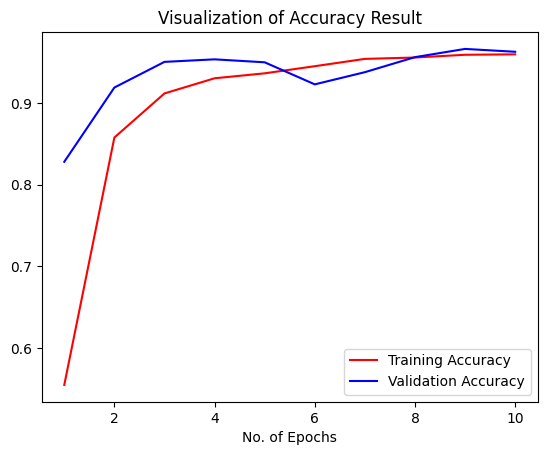

In [30]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## More Model evaluation

In [31]:
class_name = testing_set.class_names

In [32]:
class_name


['Apple - Apple Scab',
 'Apple - Healthy',
 'Bell Pepper - Bacterial Spot',
 'Bell Pepper - Healthy',
 'Cherry - Healthy',
 'Cherry - Powdery Mildew',
 'Corn (Maize) - Cercospora Leaf Spot',
 'Corn (Maize) - Healthy',
 'Grape - Black Rot',
 'Grape - Healthy',
 'Peach - Bacterial Spot',
 'Peach - Healthy',
 'Potato - Early Blight',
 'Potato - Healthy',
 'Strawberry - Healthy',
 'Strawberry - Leaf Scorch',
 'Tomato - Healthy',
 'Tomato - Septoria Leaf Spot']

In [33]:
testing_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,                                  # shuffle false
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 7440 files belonging to 18 classes.


In [ ]:
## we will use validation set as 'test set'

In [34]:
y_pred = model.predict (testing_set) 
y_pred 

233/233 [==============================] - 5s 19ms/step


array([[9.9997401e-01, 4.3362419e-10, 8.1993148e-11, ..., 5.8195153e-13,
        2.7778688e-14, 1.7444017e-09],
       [1.0000000e+00, 1.4091382e-17, 3.3506316e-14, ..., 7.8022400e-19,
        1.8475888e-20, 1.8494613e-12],
       [1.0000000e+00, 5.2140358e-18, 8.8917082e-16, ..., 7.5140244e-19,
        1.7677552e-21, 3.2395213e-13],
       ...,
       [1.0085100e-06, 3.9689077e-10, 9.1860493e-05, ..., 2.0170461e-04,
        1.5745314e-05, 9.9404013e-01],
       [6.3953035e-02, 5.3209876e-12, 4.5486789e-08, ..., 4.4322563e-11,
        2.5425875e-10, 9.3604678e-01],
       [2.9750035e-08, 2.4714056e-10, 1.0386086e-06, ..., 7.2508394e-10,
        1.3097883e-09, 9.9999547e-01]], dtype=float32)

In [35]:
y_pred.shape   # It will show probabilty of each image belonging to 18 classes.

(7440, 18)

In [36]:
predicted_categories = tf.argmax(y_pred, axis=1)  # argmax will return the maximum valum, axis= 1 means return the index in columnwise fashion, i,e vertically count the maximum value. 

In [37]:
predicted_categories

<tf.Tensor: shape=(7440,), dtype=int64, numpy=array([ 0,  0,  0, ..., 17, 17, 17], dtype=int64)>

In [38]:
true_categories = tf.concat([y for x, y in testing_set], axis=0)   # axis =0 means i want to concat in row wise fashion.
true_categories

<tf.Tensor: shape=(7440, 18), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [39]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(7440,), dtype=int64, numpy=array([ 0,  0,  0, ..., 17, 17, 17], dtype=int64)>

In [40]:
from sklearn.metrics import classification_report, confusion_matrix

In [41]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))  # precision and recall calculation for each class of the dataset

                                     precision    recall  f1-score   support

                 Apple - Apple Scab       0.89      0.99      0.94       453
                    Apple - Healthy       0.95      0.91      0.93       451
       Bell Pepper - Bacterial Spot       0.95      0.94      0.95       430
              Bell Pepper - Healthy       0.96      0.88      0.92       447
                   Cherry - Healthy       0.95      0.99      0.97       410
            Cherry - Powdery Mildew       0.98      0.98      0.98       378
Corn (Maize) - Cercospora Leaf Spot       0.96      1.00      0.98       369
             Corn (Maize) - Healthy       1.00      1.00      1.00       418
                  Grape - Black Rot       1.00      1.00      1.00       424
                    Grape - Healthy       1.00      0.99      1.00       380
             Peach - Bacterial Spot       0.98      0.90      0.94       413
                    Peach - Healthy       0.96      0.98      0.97       38

<Axes: >

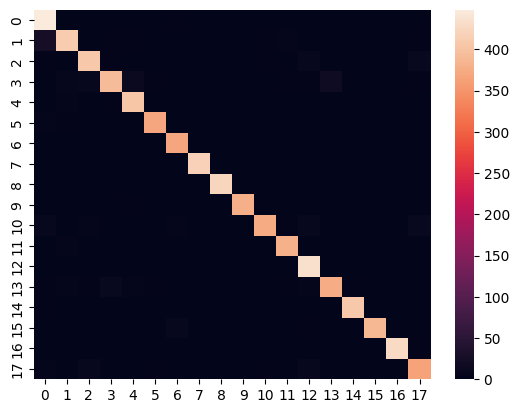

In [44]:
sns.heatmap(cm)

In [45]:
cm = confusion_matrix(Y_true,predicted_categories)

In [46]:
cm.shape

(18, 18)

## confusion matrix visualization

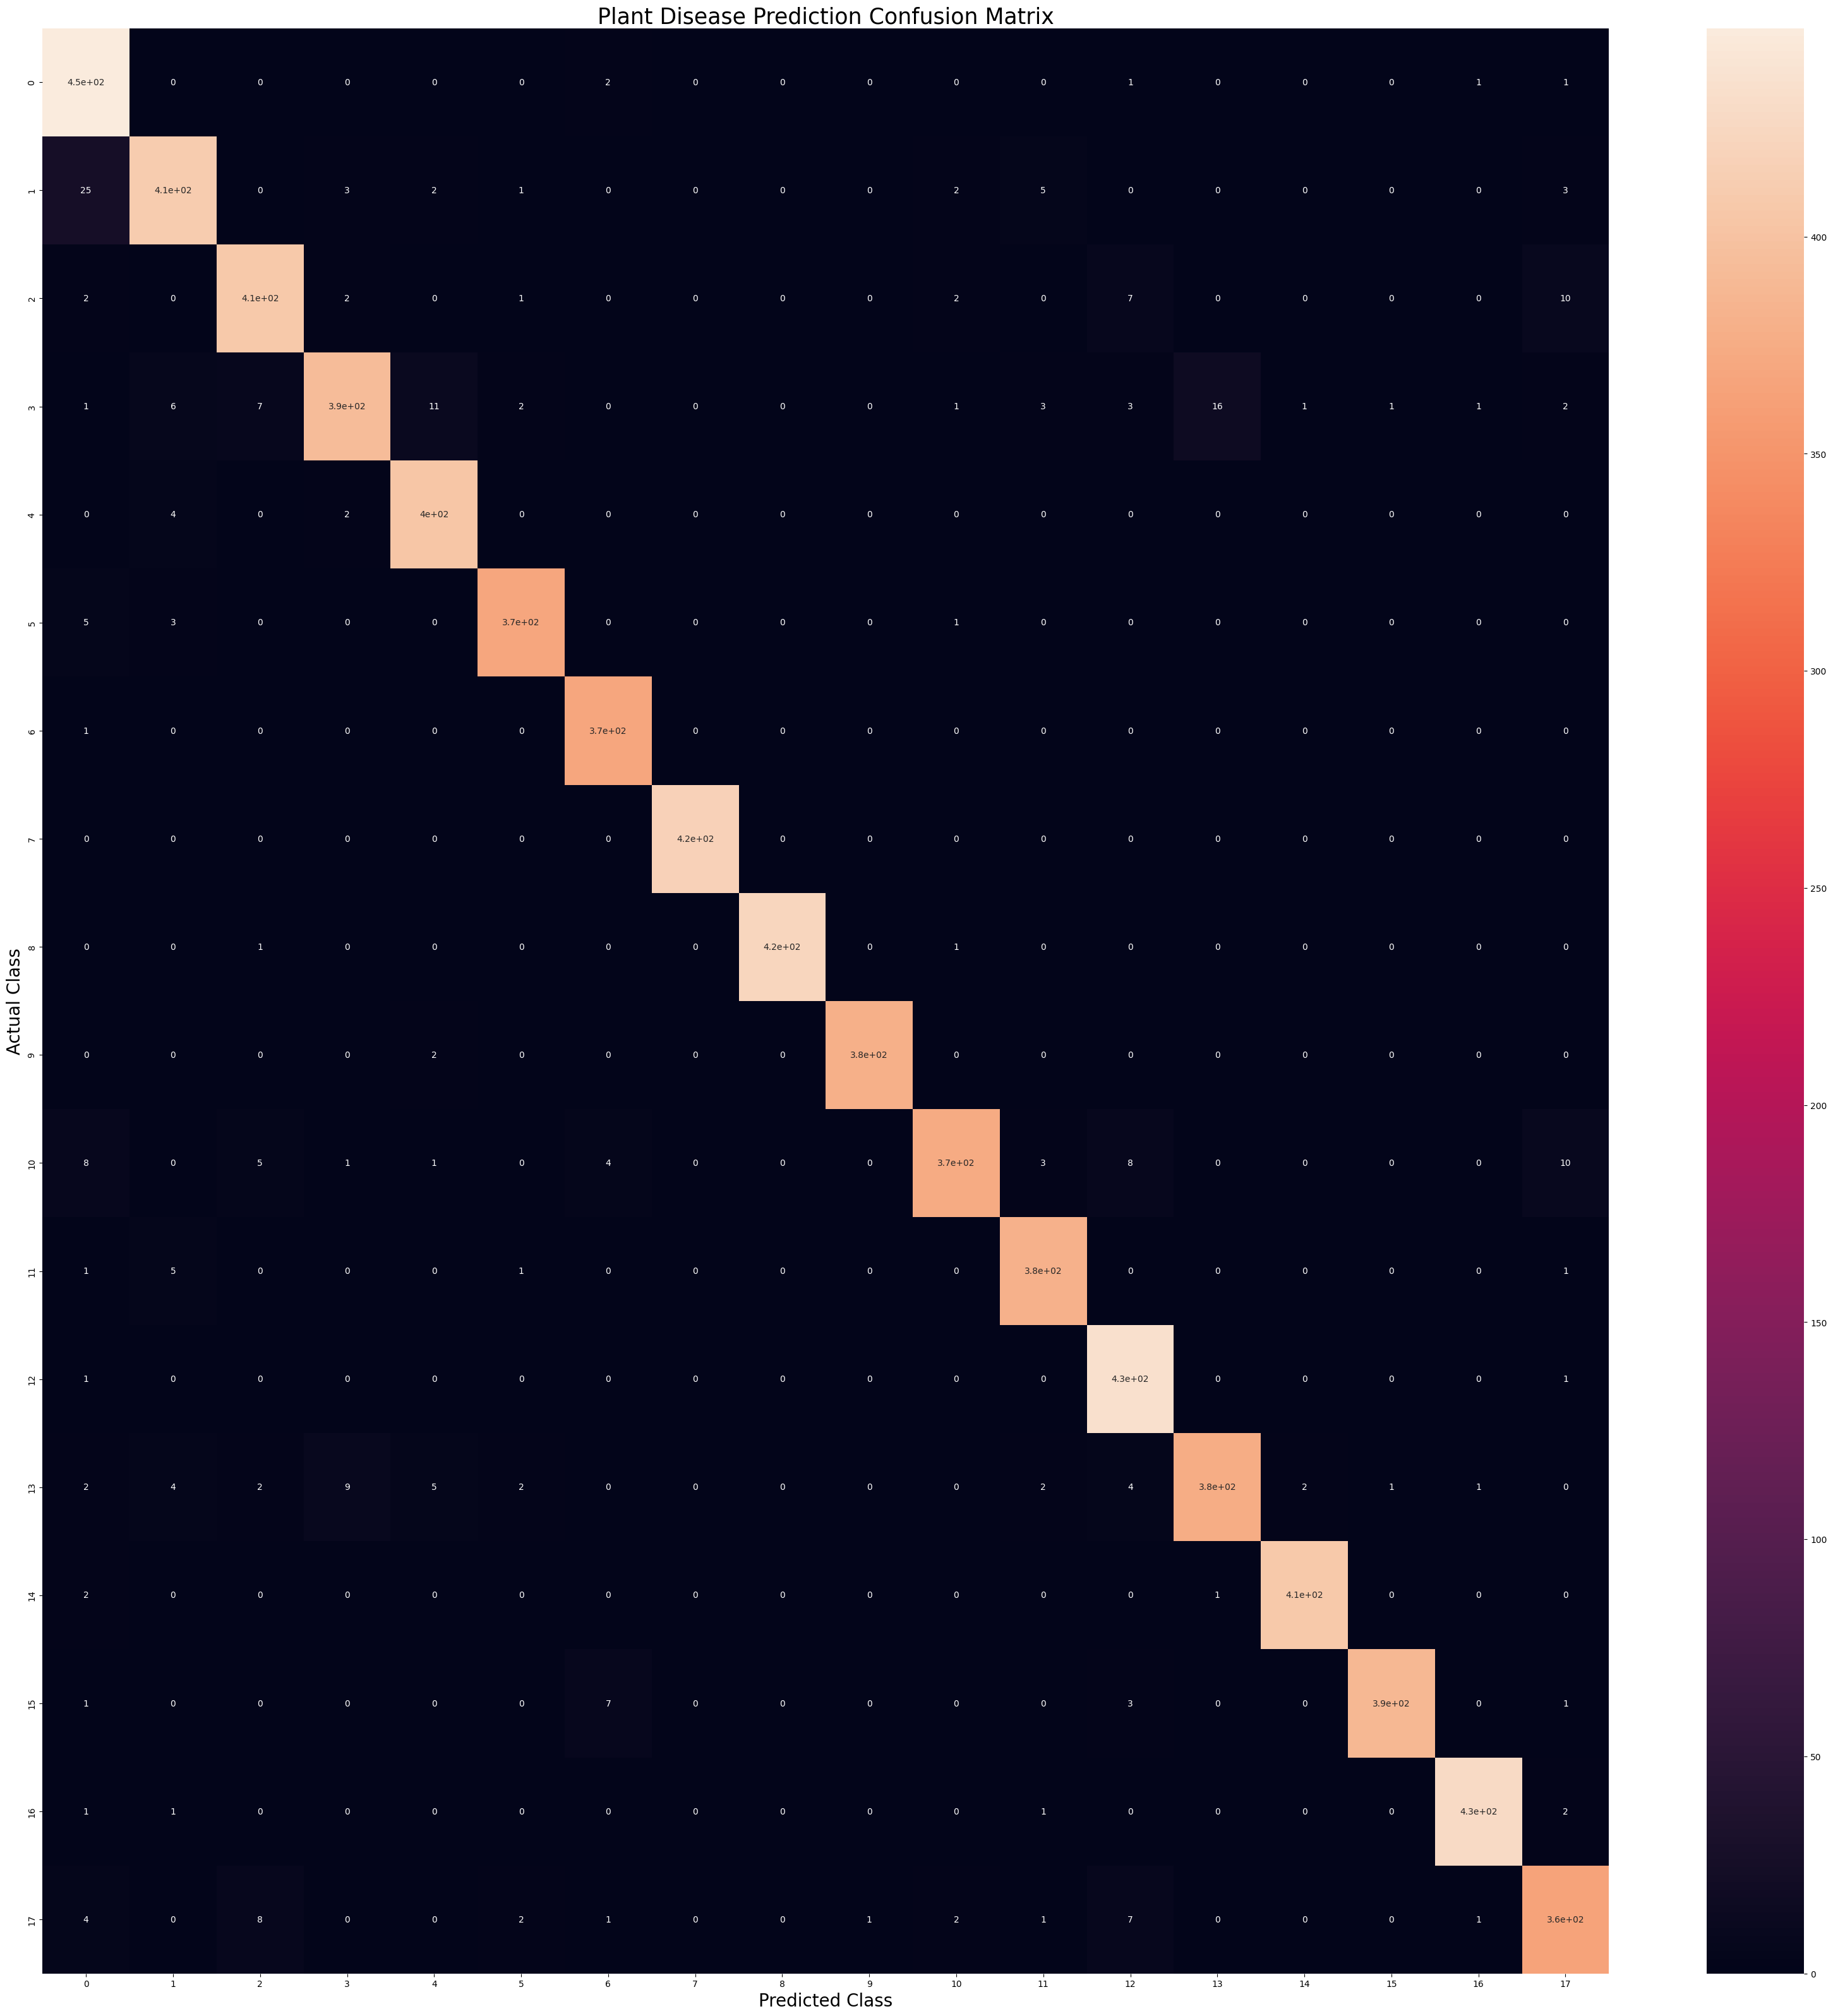

In [47]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm, annot= True, annot_kws= {'size':10})
plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()